## 1. Presentación del dataset
Mostrar cantidad de clases (70 razas), total de imágenes por split (train/valid/test), y un gráfico de barras con las imágenes por raza para ver si hay balance o desbalance de clases.

In [20]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys
import cv2
import random

In [21]:
DATASET_ROOT = Path("data/dataset")

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "valid"
TEST_DIR = DATASET_ROOT / "test"

In [ ]:
def crear_dataframe(split_dir, split_name):
    
    rows = []

    for breed_dir in sorted(split_dir.iterdir()):

        if not breed_dir.is_dir():
            continue

        breed = breed_dir.name

        for img_path in breed_dir.glob("*"):

            rows.append({
                "split": split_name,
                "breed": breed,
                "path": str(img_path)
            })

    return pd.DataFrame(rows)


train_df = crear_dataframe(TRAIN_DIR, "train")
val_df   = crear_dataframe(VAL_DIR, "val")
test_df  = crear_dataframe(TEST_DIR, "test")

df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True)

df.head()

,split,breed,path
0,train,Afghan,data\dataset\train\Afghan\001.jpg
1,train,Afghan,data\dataset\train\Afghan\002.jpg
2,train,Afghan,data\dataset\train\Afghan\003.jpg
3,train,Afghan,data\dataset\train\Afghan\004.jpg
4,train,Afghan,data\dataset\train\Afghan\005.jpg


In [23]:
print("Total imágenes:", len(df))
print("Cantidad de razas:", df["breed"].nunique())

print("\nTrain:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Total imágenes: 9346
Cantidad de razas: 70

Train: 7946
Validation: 700
Test: 700


In [ ]:
#!mv "data/dataset/valid/American  Spaniel" "data/dataset/valid/American Spaniel"

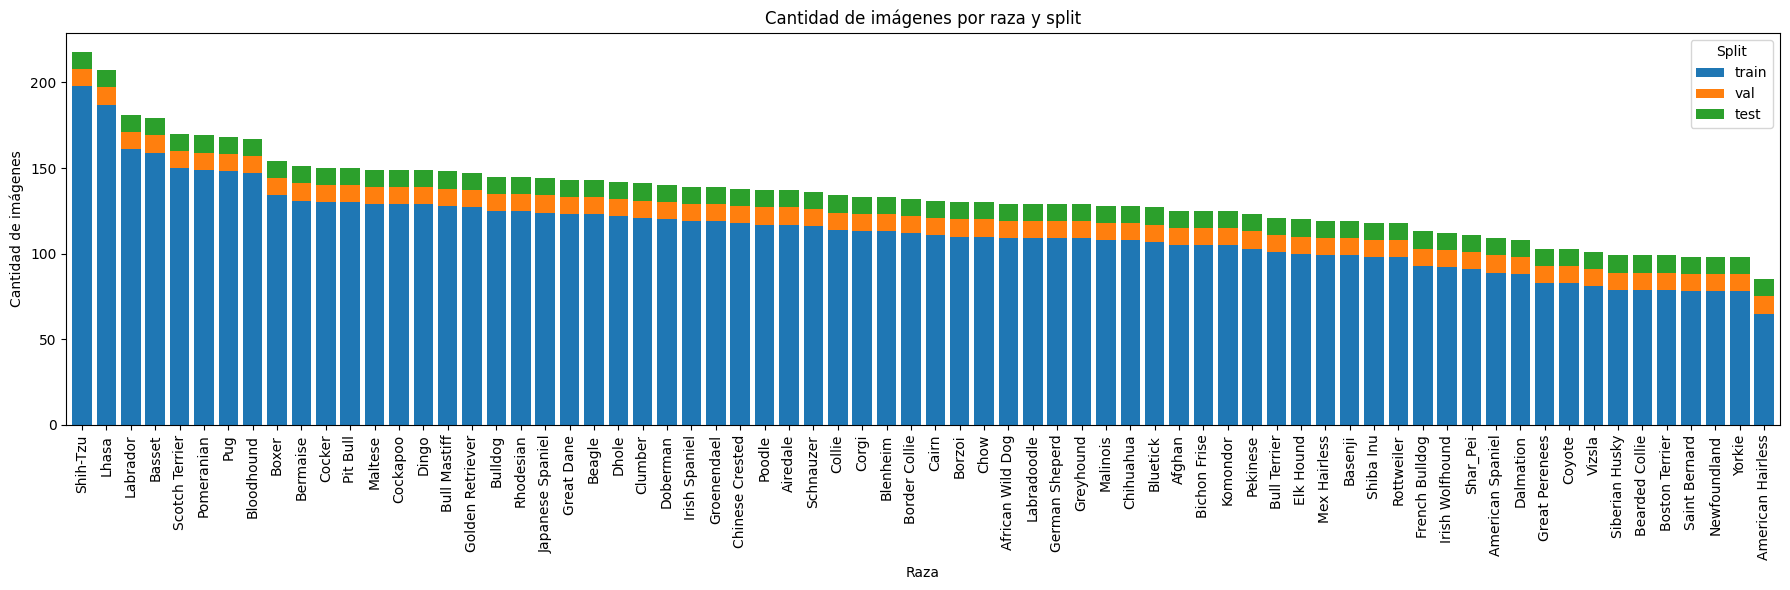

In [24]:
summary = pd.DataFrame({
    "train": train_df["breed"].value_counts(),
    "val": val_df["breed"].value_counts(),
    "test": test_df["breed"].value_counts()
}).fillna(0)

summary = summary.sort_index()

summary["total"] = summary.sum(axis=1)

summary = summary.sort_values(
    by="total",
    ascending=False
)

summary[["train", "val", "test"]].plot(
    kind="bar",
    stacked=True,
    figsize=(18, 6),
    width=0.8
)

plt.title("Cantidad de imágenes por raza y split")
plt.xlabel("Raza")
plt.ylabel("Cantidad de imágenes")

plt.legend(title="Split")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## 2. Exploración visual
Mostrar una grilla con imágenes de ejemplo de cada raza. Acá también conviene mostrar variedad dentro de una misma raza (distintas poses, iluminaciones, fondos) para justificar por qué se necesita augmentation.

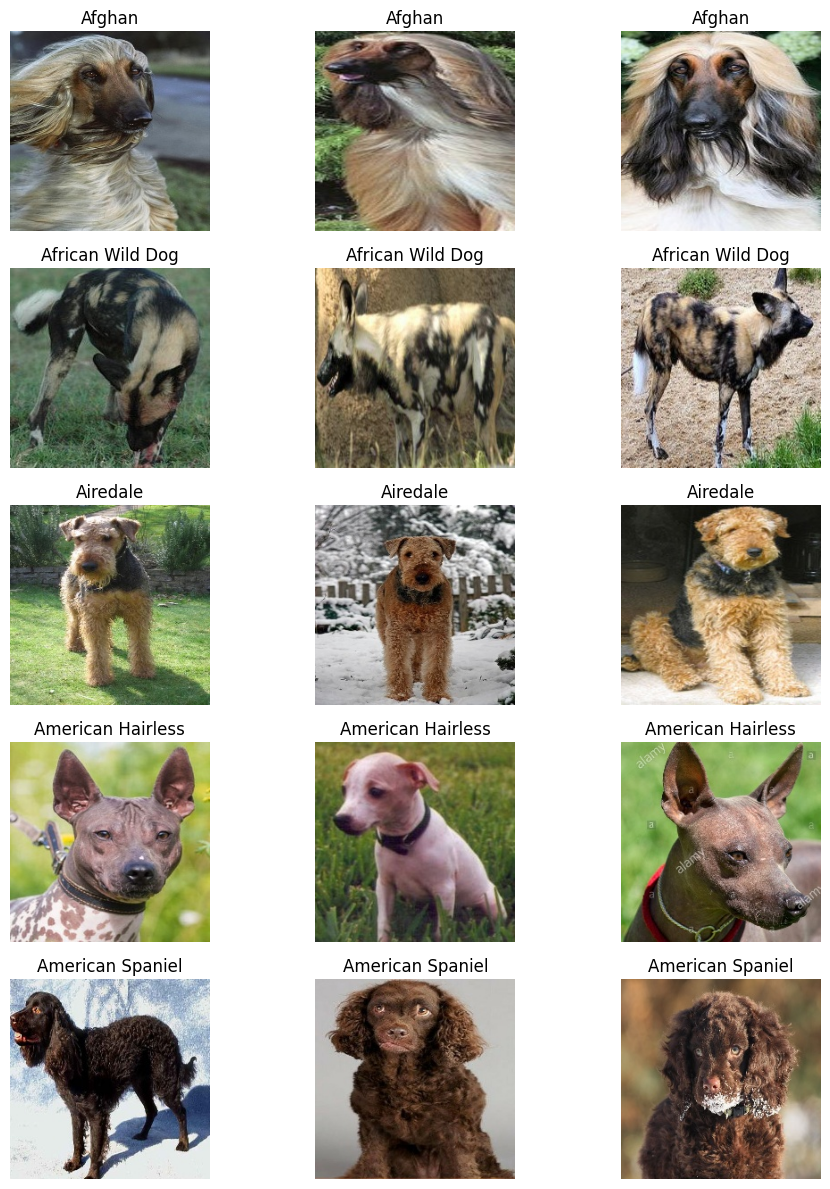

In [25]:
def show_examples(df, n_breeds=5):

    breeds = df["breed"].unique()[:n_breeds]

    fig, axes = plt.subplots(
        n_breeds,
        3,
        figsize=(10, 12)
    )

    for row, breed in enumerate(breeds):

        samples = df[df["breed"] == breed].sample(3)

        for col, (_, sample) in enumerate(samples.iterrows()):

            img = Image.open(sample["path"])

            axes[row, col].imshow(img)
            axes[row, col].set_title(breed)
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()


show_examples(train_df)

## 3. Análisis de calidad del dataset

Distribución de resoluciones (ancho y alto de las imágenes)
Detección de imágenes muy pequeñas o corruptas
Ratio de aspecto (¿son cuadradas o rectangulares?)

Esto justifica el resize que aplicás en el preprocesamiento.

In [26]:
sizes = []

for path in df["path"]:

    img = Image.open(path)

    sizes.append(img.size)

sizes_df = pd.DataFrame(
    sizes,
    columns=["width", "height"]
)

sizes_df.value_counts()

width  height
224    224       9346
Name: count, dtype: int64

## 5. Modelo elegido para embeddings
EfficientNet-B0 elegido sobre ResNet50 ya que proporciona embeddings de igual o mejor calidad representativa con una fracción del costo computacional

## 6. Generación y análisis de embeddings

Generacion de embeddings del dataset de train y  visualizar con t-SNE para ver si las razas se agrupan.

In [ ]:
ROOT = Path.cwd()
SRC = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

os.chdir(SRC if (SRC / ".env").is_file() else ROOT)

from lib.bootstrap import build_similarity, build_store
from lib.config import settings

store = build_store(settings)
similarity = build_similarity(settings, store)

if settings.embedding_model == "baseline":
    similarity.extract_embedding = similarity.extract_embedding 
else:
    from lib.bootstrap import build_classifier
    classifier = build_classifier(settings)
    classifier.set_active_model(settings.embedding_model)
    similarity.extract_embedding = classifier.extract_custom_embedding

print(f"Modelo actual: {settings.embedding_model}")

INFO:lib.bootstrap:Using PostgreSQL vector store


Modelo actual: baseline


### Visualizacion t-SNE

Se grafican una cantidad reducida de razas y cantidad de imagenes para poder visualizar los embeddings en 2 dimensiones.

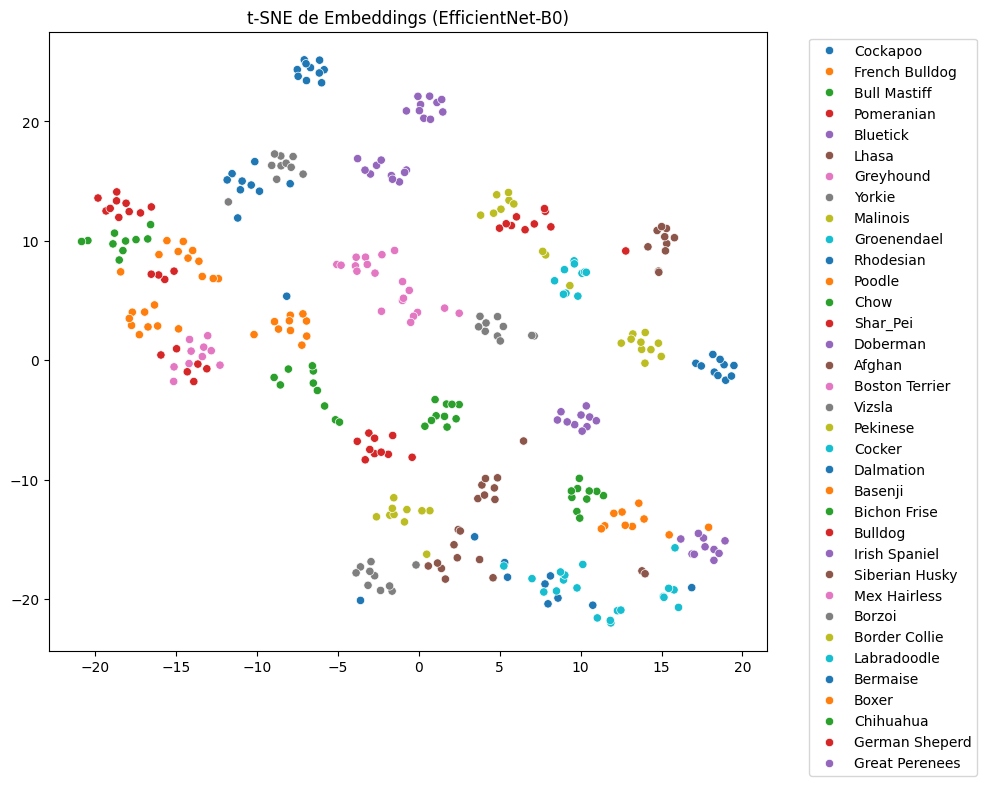

In [ ]:

NUM_BREEDS_TO_PLOT = 35
SAMPLES_PER_BREED = 10

def get_embeddings_for_viz(similarity_service, dataset_path, split="train"):
    split_dir = Path(dataset_path) / split
    all_breeds = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    
    selected_breeds = random.sample(all_breeds, NUM_BREEDS_TO_PLOT)
    
    X = []
    y = []
    
    for breed in selected_breeds:
        breed_dir = split_dir / breed
        images = list(breed_dir.glob("*.jpg"))
   
        sample_images = random.sample(images, min(SAMPLES_PER_BREED, len(images)))
        
        for img_path in sample_images:
            image = cv2.imread(str(img_path))
            if image is not None:
                emb = similarity_service.extract_embedding(image)
                X.append(emb)
                y.append(breed)
                
    return np.array(X), np.array(y)


X, y = get_embeddings_for_viz(similarity, settings.dataset_path, split="train")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42) 
X_tsne = tsne.fit_transform(X)

# Visualización
plt.figure(figsize=(10, 8))

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="tab10")
plt.title("t-SNE de Embeddings (EfficientNet-B0)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 8. Evaluación — NDCG@10
Calcular NDCG@10 sobre el set de test, explicar qué mide y justificar el resultado. Esta es la métrica que pide explícitamente el enunciado.

In [ ]:
sys.path.append(str(Path.cwd().parent / "src")) 

from lib.evaluation.metrics import ndcg_at_k

def evaluate_test_set(similarity_service, dataset_path, top_k=10):
    test_dir = Path(dataset_path) / "test"
    
    breeds = sorted([d for d in test_dir.iterdir() if d.is_dir()])
    ndcg_scores = []
    
    for breed_dir in breeds:
        true_breed = breed_dir.name
        
        for img_path in breed_dir.glob("*.jpg"):
            image = cv2.imread(str(img_path))
            if image is None:
                continue
                
            query_embedding = similarity_service.extract_embedding(image)
    
            neighbors = similarity_service.search_similar_images(query_embedding, top_k=top_k)
    
            relevances = [1.0 if n.breed == true_breed else 0.0 for n in neighbors]
            
            # Calcular y guardar el NDCG@10
            score = ndcg_at_k(relevances, k=top_k) 
            ndcg_scores.append(score)
            
    mean_ndcg = np.mean(ndcg_scores)
    print(f"\nResultados Finales:")
    print(f"Total de imágenes evaluadas: {len(ndcg_scores)}")
    print(f"NDCG@{top_k} Promedio: {mean_ndcg:.4f}")
    
    return mean_ndcg


mean_score = evaluate_test_set(similarity, settings.dataset_path, top_k=10)


Resultados Finales:
Total de imágenes evaluadas: 700
NDCG@10 Promedio: 0.9716
